In [2]:
import pandas as pd

# โหลดข้อมูล
data = pd.read_csv('../data/telco_churn.csv')  # ../data/ เพราะ notebook อยู่ในโฟลเดอร์ notebooks
print(data.head())
print(data.info())
print(data.isnull().sum())


   customerID  gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0  7590-VHVEG  Female              0     Yes         No       1           No   
1  5575-GNVDE    Male              0      No         No      34          Yes   
2  3668-QPYBK    Male              0      No         No       2          Yes   
3  7795-CFOCW    Male              0      No         No      45           No   
4  9237-HQITU  Female              0      No         No       2          Yes   

      MultipleLines InternetService OnlineSecurity  ... DeviceProtection  \
0  No phone service             DSL             No  ...               No   
1                No             DSL            Yes  ...              Yes   
2                No             DSL            Yes  ...               No   
3  No phone service             DSL            Yes  ...              Yes   
4                No     Fiber optic             No  ...               No   

  TechSupport StreamingTV StreamingMovies        Contract Pape

In [3]:
data['TotalCharges'] = pd.to_numeric(data['TotalCharges'], errors='coerce')
data = data.dropna()  # ลบ row ที่มีค่า missing


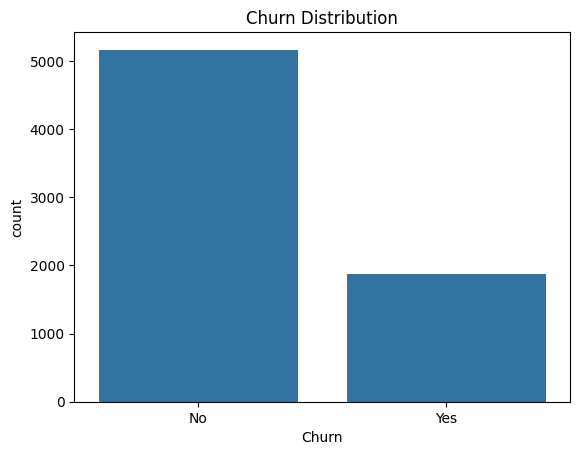

In [4]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x='Churn', data=data)
plt.title("Churn Distribution")
plt.show()


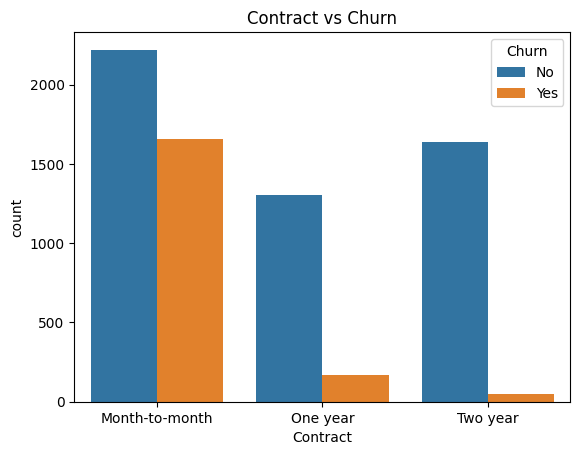

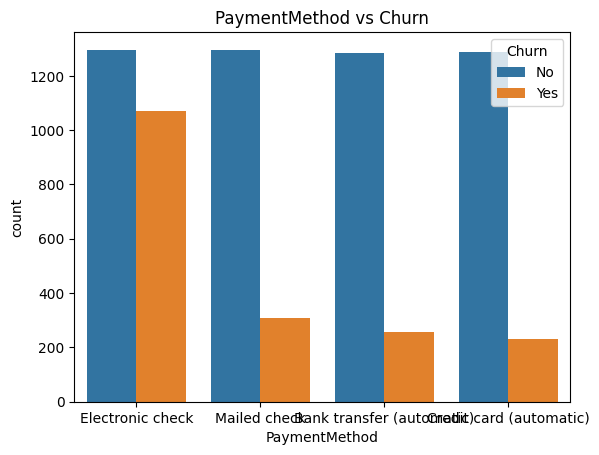

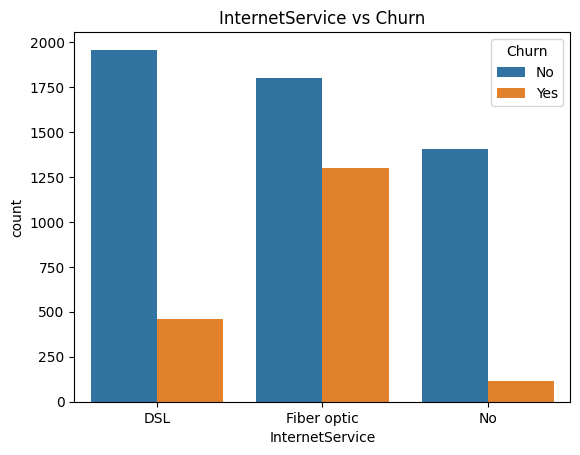

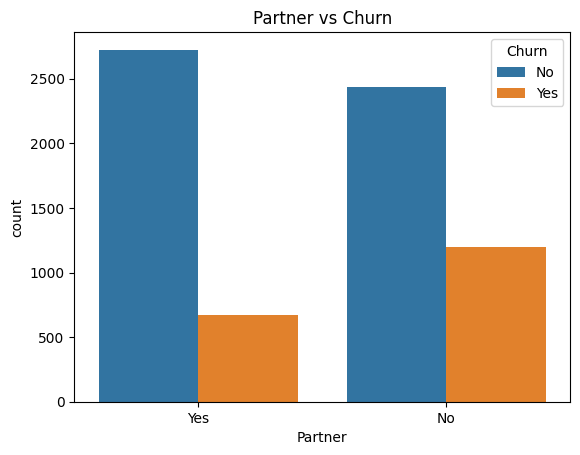

In [5]:
categorical_features = ['Contract', 'PaymentMethod', 'InternetService', 'Partner']

for col in categorical_features:
    sns.countplot(x=col, hue='Churn', data=data)
    plt.title(f"{col} vs Churn")
    plt.show()


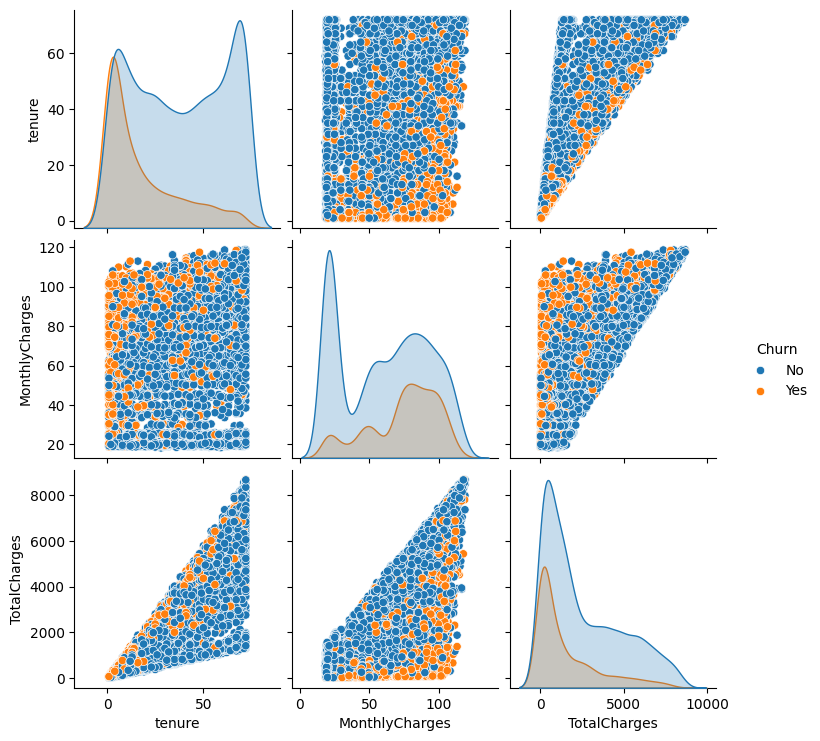

In [6]:
numeric_features = ['tenure', 'MonthlyCharges', 'TotalCharges']
sns.pairplot(data[numeric_features + ['Churn']], hue='Churn')
plt.show()


In [7]:
# เลือก categorical features
categorical_features = data.select_dtypes(include=['object']).columns.tolist()
categorical_features.remove('customerID')
categorical_features.remove('Churn')

# One-hot encoding
data_encoded = pd.get_dummies(data, columns=categorical_features, drop_first=True)


In [8]:
X = data_encoded.drop(['customerID', 'Churn'], axis=1)
y = data_encoded['Churn'].apply(lambda x: 1 if x=='Yes' else 0)


In [10]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


Accuracy: 0.7874911158493249
              precision    recall  f1-score   support

           0       0.83      0.89      0.86      1033
           1       0.62      0.52      0.56       374

    accuracy                           0.79      1407
   macro avg       0.73      0.70      0.71      1407
weighted avg       0.78      0.79      0.78      1407



C:\Users\Admin\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


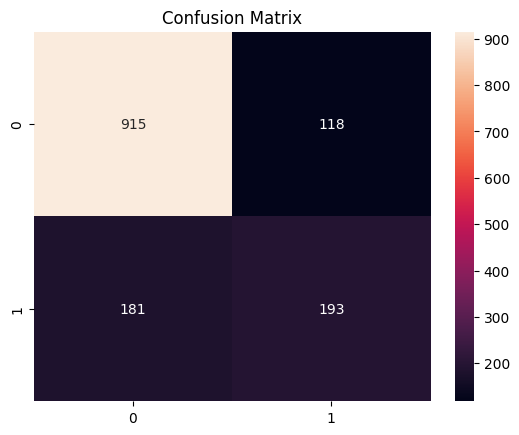

In [11]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Train model
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

# Predict
y_pred = model.predict(X_test)

# Evaluate
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

# Confusion matrix
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d')
plt.title("Confusion Matrix")
plt.show()


In [12]:
import numpy as np

coefficients = pd.DataFrame({
    'Feature': X_train.columns,
    'Coefficient': model.coef_[0]
})
coefficients['AbsCoefficient'] = coefficients['Coefficient'].abs()
coefficients = coefficients.sort_values(by='AbsCoefficient', ascending=False)
print(coefficients.head(5))  # 5 features สำคัญ


                        Feature  Coefficient  AbsCoefficient
25            Contract_Two year    -1.300212        1.300212
24            Contract_One year    -0.756150        0.756150
10  InternetService_Fiber optic     0.664479        0.664479
13           OnlineSecurity_Yes    -0.469824        0.469824
19              TechSupport_Yes    -0.446927        0.446927


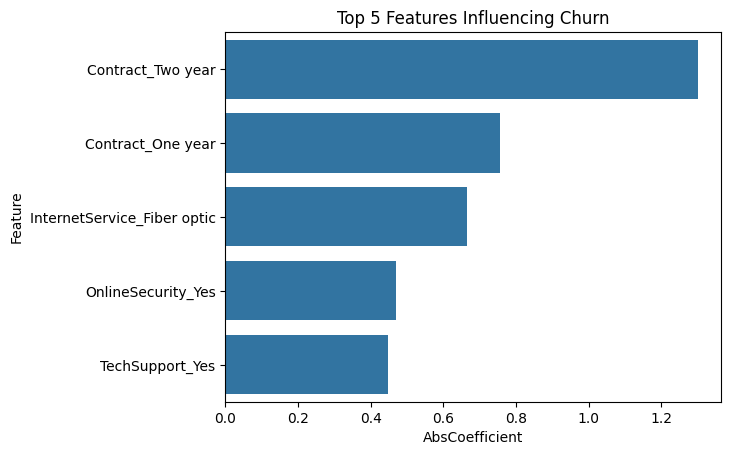

In [13]:
# Top 5 important features
top_features = coefficients.head(5)
sns.barplot(x='AbsCoefficient', y='Feature', data=top_features)
plt.title("Top 5 Features Influencing Churn")
plt.show()


In [14]:
from sklearn.metrics import roc_curve, auc, precision_recall_curve, average_precision_score
import matplotlib.pyplot as plt


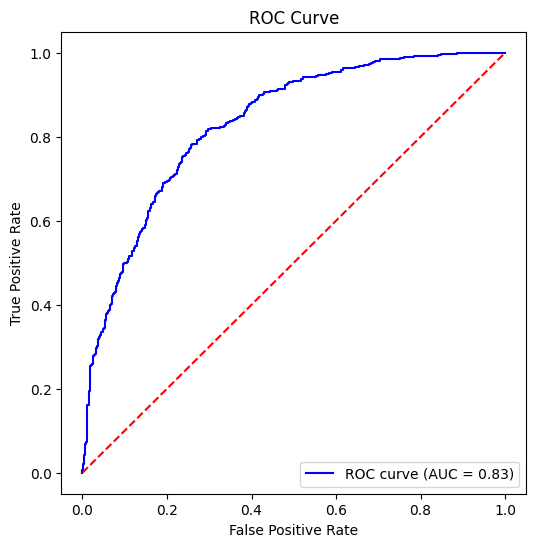

In [15]:
# ต้องใช้ probability ของ positive class
y_prob = model.predict_proba(X_test)[:, 1]

# คำนวณค่า FPR, TPR, thresholds
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

# วาด ROC Curve
plt.figure(figsize=(6,6))
plt.plot(fpr, tpr, color='blue', label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0,1], [0,1], color='red', linestyle='--')  # เส้น baseline
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend(loc='lower right')
plt.show()


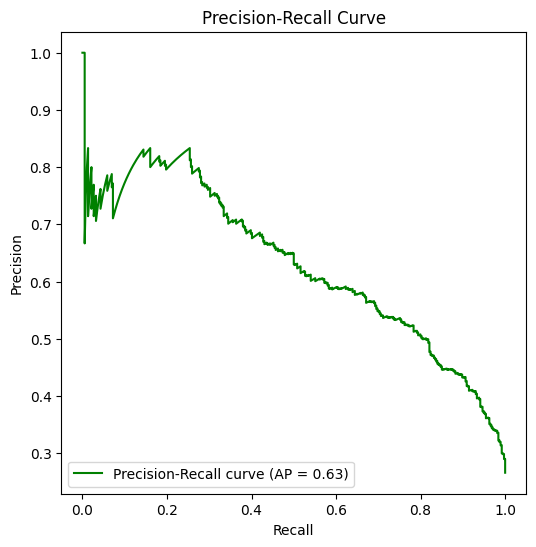

In [16]:
precision, recall, thresholds = precision_recall_curve(y_test, y_prob)
avg_precision = average_precision_score(y_test, y_prob)

# วาด Precision-Recall Curve
plt.figure(figsize=(6,6))
plt.plot(recall, precision, color='green', label=f'Precision-Recall curve (AP = {avg_precision:.2f})')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend(loc='lower left')
plt.show()
